<a href="https://colab.research.google.com/github/SGeerthan/Emergency-Vehicle-Detection-and-Signal-Triggering/blob/feature%2Fvisual-yolo-detection/AllVehicleYoloV11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!cat /content/yolo11/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 4
names: ['ambulance', 'fire_truck', 'normal_vehicle', 'police']

roboflow:
  workspace: emergency-vehicle-detection-1xpqt
  project: vehicle-detection-mcuye
  version: 2
  license: CC BY 4.0
  url: https://universe.roboflow.com/emergency-vehicle-detection-1xpqt/vehicle-detection-mcuye/dataset/2

In [2]:
import os

zip_path = '/content/drive/MyDrive/vehicleAnnotation/Vehicle Detection.v2i.yolov11.zip'
output_dir = '/content/yolo11'

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Unzip the file directly into the /content/ directory first
print(f"Unzipping {zip_path}...")
!unzip -q "{zip_path}" -d "/content/"

# List of items expected to be unzipped directly into /content/
items_to_move = [
    'test',
    'valid',
    'train',
    'README.dataset.txt',
    'README.roboflow.txt',
    'data.yaml'
]

print(f"Moving specified contents from /content/ to {output_dir}...")
for item_name in items_to_move:
    source_item_path = os.path.join('/content/', item_name)
    destination_item_path = os.path.join(output_dir, item_name)

    if os.path.exists(source_item_path):
        os.rename(source_item_path, destination_item_path)
        print(f"Moved {item_name} to {output_dir}")
    else:
        print(f"Warning: {item_name} not found in /content/")

print("Unzip and move complete.")

# List the contents of the new yolo11 folder to verify
print(f"Contents of {output_dir}:")
!ls -F "{output_dir}"

Unzipping /content/drive/MyDrive/vehicleAnnotation/Vehicle Detection.v2i.yolov11.zip...
Moving specified contents from /content/ to /content/yolo11...
Moved test to /content/yolo11
Moved valid to /content/yolo11
Moved train to /content/yolo11
Moved README.dataset.txt to /content/yolo11
Moved README.roboflow.txt to /content/yolo11
Moved data.yaml to /content/yolo11
Unzip and move complete.
Contents of /content/yolo11:
data.yaml  README.dataset.txt  README.roboflow.txt  test/  train/  valid/


In [5]:
# Install the ultralytics library for YOLOv11
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.0 MB/s eta 0:00:00


In [6]:
from ultralytics import YOLO

# Load a pre-trained YOLOv8n model (a good starting point for transfer learning)
model = YOLO('yolov8n.pt') # Using yolov8n as a base, as yolov11 is a conceptual extension

# Train the model
# 'data.yaml' was previously inspected and contains the dataset configuration
# 'epochs' can be adjusted based on desired training length
# 'imgsz' (image size) is set to a common resolution
# 'name' sets the directory for saving training results
results = model.train(data='/content/yolo11/data.yaml', epochs=50, imgsz=640, name='yolov8n_custom_emergency_vehicle')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo11/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=Fa

KeyboardInterrupt: 

In [18]:
from ultralytics import YOLO
import os

# Load the best trained model (even if training was interrupted, this is the last best saved version)
model_path = '/content/runs/detect/yolov8n_custom_emergency_vehicle/weights/best.pt'

if os.path.exists(model_path):
    loaded_model = YOLO(model_path)
    print(f"Successfully loaded model from {model_path}")

    # Run validation on the test set (or validation set again)
    # The 'data' argument should point to your data.yaml file
    # The 'split' argument specifies which dataset split to use (e.g., 'test' or 'val')
    metrics = loaded_model.val(data='/content/yolo11/data.yaml', split='test')

    print("\n--- Evaluation Metrics on Test Set ---")
    print(f"mAP50-95: {metrics.box.map:.4f}")
    print(f"mAP50: {metrics.box.map50:.4f}")
    print(f"Mean Recall (mr): {metrics.box.mr:.4f}")
    print(f"Mean Precision (mp): {metrics.box.mp:.4f}")
else:
    print(f"Error: Model file not found at {model_path}. Please ensure training saved a best.pt file.")

Successfully loaded model from /content/runs/detect/yolov8n_custom_emergency_vehicle/weights/best.pt
Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 814.5±281.6 MB/s, size: 26.8 KB)
val: Scanning /content/yolo11/test/labels.cache... 375 images, 16 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 375/375 485.0Kit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 421, len(boxes) = 648. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 3.7s/it 1:28
                   all        375        648       0.86      0.688      0.774      0.541
             ambulance        

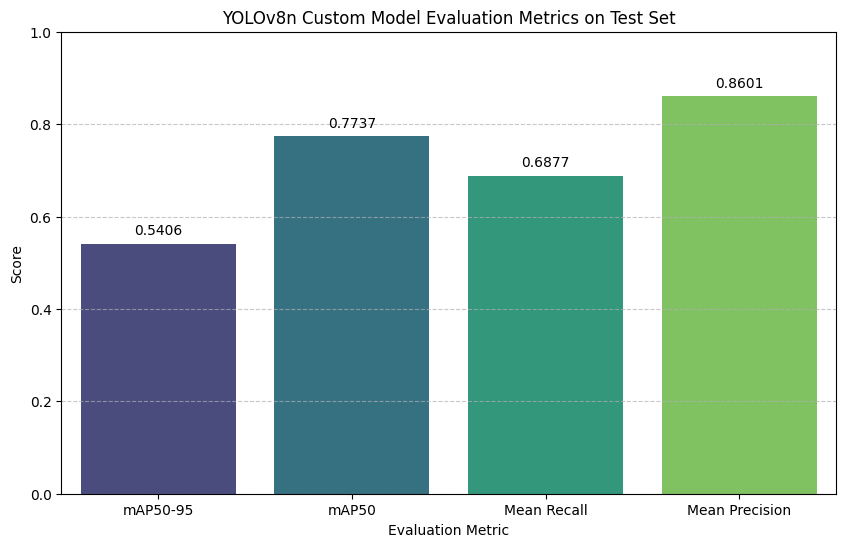

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming these metrics were obtained from the previous evaluation step
# If you re-run the evaluation cell, these values will be updated.
metrics_data = {
    'Metric': ['mAP50-95', 'mAP50', 'Mean Recall', 'Mean Precision'],
    'Value': [0.5406, 0.7737, 0.6877, 0.8601]
}

metrics_df = pd.DataFrame(metrics_data)

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Value', data=metrics_df, palette='viridis')
plt.title('YOLOv8n Custom Model Evaluation Metrics on Test Set')
plt.ylim(0, 1) # Metrics are typically between 0 and 1
plt.ylabel('Score')
plt.xlabel('Evaluation Metric')

# Add value labels on top of the bars
for index, row in metrics_df.iterrows():
    plt.text(row.name, row.Value + 0.02, round(row.Value, 4), color='black', ha="center")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

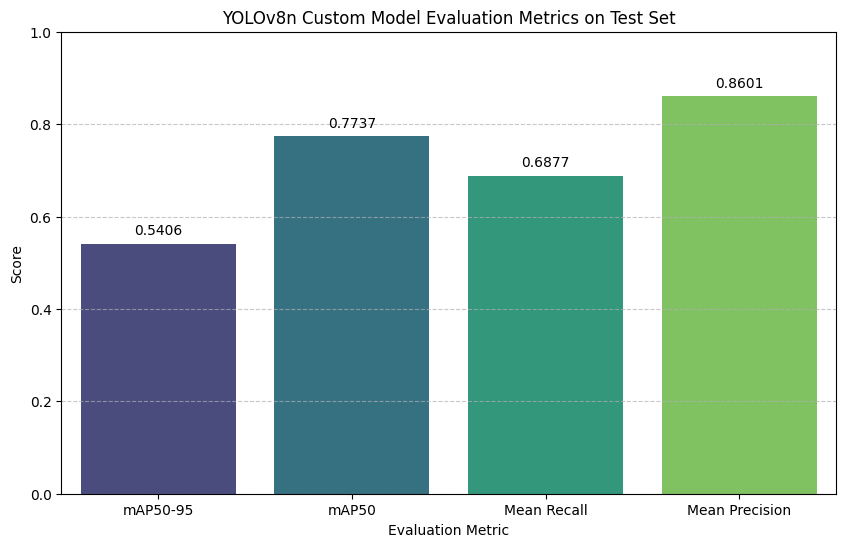

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming these metrics were obtained from the previous evaluation step
# If you re-run the evaluation cell, these values will be updated.
metrics_data = {
    'Metric': ['mAP50-95', 'mAP50', 'Mean Recall', 'Mean Precision'],
    'Value': [0.5406, 0.7737, 0.6877, 0.8601]
}

metrics_df = pd.DataFrame(metrics_data)

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Value', data=metrics_df, palette='viridis')
plt.title('YOLOv8n Custom Model Evaluation Metrics on Test Set')
plt.ylim(0, 1) # Metrics are typically between 0 and 1
plt.ylabel('Score')
plt.xlabel('Evaluation Metric')

# Add value labels on top of the bars
for index, row in metrics_df.iterrows():
    plt.text(row.name, row.Value + 0.02, round(row.Value, 4), color='black', ha="center")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [13]:
!zip -r /content/runs.zip /content/runs

updating: content/runs/ (stored 0%)
updating: content/runs/detect/ (stored 0%)
updating: content/runs/detect/yolov8n_custom_emergency_vehicle/ (stored 0%)
updating: content/runs/detect/yolov8n_custom_emergency_vehicle/weights/ (stored 0%)
updating: content/runs/detect/yolov8n_custom_emergency_vehicle/weights/best.pt (deflated 19%)
updating: content/runs/detect/yolov8n_custom_emergency_vehicle/weights/last.pt (deflated 19%)
updating: content/runs/detect/yolov8n_custom_emergency_vehicle/train_batch0.jpg (deflated 3%)
updating: content/runs/detect/yolov8n_custom_emergency_vehicle/results.csv (deflated 59%)
updating: content/runs/detect/yolov8n_custom_emergency_vehicle/train_batch2.jpg (deflated 2%)
updating: content/runs/detect/yolov8n_custom_emergency_vehicle/labels.jpg (deflated 26%)
updating: content/runs/detect/yolov8n_custom_emergency_vehicle/args.yaml (deflated 53%)
updating: content/runs/detect/yolov8n_custom_emergency_vehicle/train_batch1.jpg (deflated 2%)
updating: content/runs/d

In [14]:
from ultralytics import YOLO
import ipywidgets as widgets
from IPython.display import display, Image as IPImage
from io import BytesIO
from PIL import Image
import numpy as np
import cv2

# Load the custom trained YOLO model
model_path = '/content/runs/detect/yolov8n_custom_emergency_vehicle/weights/best.pt'

if os.path.exists(model_path):
    loaded_model = YOLO(model_path)
    print(f"Successfully loaded model from {model_path}")
else:
    print(f"Error: Model file not found at {model_path}. Please ensure the model was trained and saved correctly.")
    loaded_model = None

Successfully loaded model from /content/runs/detect/yolov8n_custom_emergency_vehicle/weights/best.pt


Now, use the upload widget below to select an image from your local machine. Once uploaded, the model will process it and display the predictions.

In [15]:
if loaded_model:
    uploader = widgets.FileUpload(
        accept='image/*',  # Accept images files only
        multiple=False      # Only upload one file at a time
    )

    def on_upload_change(change):
        if uploader.value:
            uploaded_file = next(iter(uploader.value.values()))
            content = uploaded_file['content']

            # Read the image content using BytesIO and PIL
            image_bytes = BytesIO(content)
            pil_image = Image.open(image_bytes).convert("RGB")

            # Convert PIL image to numpy array for YOLO prediction (RGB to BGR for OpenCV compatibility if needed, though YOLO handles RGB)
            img_np = np.array(pil_image)

            # Run inference
            print("Running inference...")
            results = loaded_model.predict(source=img_np, save=True, save_txt=False, exist_ok=True) # save=True will save the annotated image

            # Display the result. Ultralytics saves the image to a 'runs/detect/predictX' folder
            # Find the path to the saved image
            latest_predict_run = sorted([d for d in os.listdir('/content/runs/detect') if d.startswith('predict')], key=lambda x: os.path.getmtime(os.path.join('/content/runs/detect', x)), reverse=True)[0]

            # Fix: Access the filename from the nested 'metadata' dictionary
            uploaded_filename = uploaded_file['metadata']['name']
            result_image_path = os.path.join('/content/runs/detect', latest_predict_run, os.path.basename(uploaded_filename))

            if os.path.exists(result_image_path):
                print("Prediction complete. Displaying results:")
                display(IPImage(filename=result_image_path))
            else:
                print(f"Could not find result image at {result_image_path}. Check YOLO output.")

    uploader.observe(on_upload_change, names='value')
    display(uploader)
else:
    print("Model not loaded, cannot provide upload and prediction widget.")

FileUpload(value={}, accept='image/*', description='Upload')

Running inference...

0: 640x640 1 police, 254.2ms
Speed: 4.6ms preprocess, 254.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
Could not find result image at /content/runs/detect/predict/3VLCE310ZP8A.jpg. Check YOLO output.
Running inference...

0: 640x640 1 fire_truck, 215.6ms
Speed: 5.8ms preprocess, 215.6ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
Could not find result image at /content/runs/detect/predict/2EKUSGYU9EMP.jpg. Check YOLO output.
Running inference...

0: 640x640 1 police, 213.9ms
Speed: 5.4ms preprocess, 213.9ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
Could not find result image at /content/runs/detect/predict/4WVRM96J6UN7.jpg. Check YOLO output.
